# Dual-Signal SBFL: Perturbation Calibration, Stronger Oracle, Hop-Depth Completeness

This notebook demonstrates **Spectrum-Based Fault Localization (SBFL)** applied to Prolog knowledge bases extracted from natural language premises (ProofWriter dataset).

**What this does:**
1. Extracts a Prolog KB from natural language premises using an LLM (Claude Haiku)
2. Generates oracle yes/no queries about the KB using an LLM
3. Runs each query via a depth-limited SWI-Prolog meta-interpreter (subprocess-based)
4. Computes **Ochiai suspiciousness scores** across predicates
5. Harvests missing subgoal predicates as a second signal
6. Performs **iterative SBFL-guided repair** of erroneous/missing predicates

**Three sub-experiments:**
- **A**: Perturbation calibration — inject synthetic KB errors, measure Spearman ρ between Ochiai scores and ground-truth perturbed predicates
- **B**: Oracle model comparison — Haiku vs GPT-4o-mini as oracle generators
- **C**: KB completeness by hop depth — stratify examples by rule count, measure completeness rates

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('loguru==0.7.2')
_pip('tenacity==8.2.3')
_pip('openai>=1.52.0')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import random
import re
import resource
import subprocess
import sys
import tempfile
import time
from pathlib import Path
from typing import Any, Optional

import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
from scipy.stats import spearmanr
from tenacity import retry, stop_after_attempt, wait_exponential

import openai

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-d8d250-dual-signal-spectrum-based-fault-localiz/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["examples"]
print(f"Loaded {len(examples)} examples")
print(f"Example keys: {list(examples[0].keys())}")

Loaded 3 examples
Example keys: ['input', 'output', 'metadata_fold', 'metadata_split', 'metadata_is_calibration_doc', 'metadata_gold_label', 'metadata_premises_text', 'metadata_conclusion', 'metadata_gold_fol_premises', 'metadata_gold_fol_conclusion', 'metadata_story_id', 'metadata_example_id', 'metadata_task_type', 'metadata_fold_name', 'predict_baseline', 'predict_dual_sbfl']


## Configuration

All tunable parameters are defined here. Set to **minimum values** for a fast demo run.
To reproduce the full paper results, use the commented-out original values.

In [5]:
HAIKU_MODEL = "anthropic/claude-3-haiku"
GPT4O_MINI_MODEL = "openai/gpt-4o-mini"
BUDGET_CAP = 6.0  # USD hard cap

# Sub-experiment A: number of docs to use for perturbation calibration
N_DOCS_A = 1          # minimum: 1  |  original: 10

# Sub-experiment B: number of examples and calibration subset
N_EXAMPLES_B = 1      # minimum: 1  |  original: 40
CALIBRATION_N_B = 1   # minimum: 1  |  original: 5

# Sub-experiment C: examples per hop depth
N_PER_DEPTH_C = 1     # minimum: 1  |  original: 30

# Baseline: number of examples for direct LLM classification
N_BASELINE = 1        # minimum: 1  |  original: 40

# Per-example predictions (schema output)
MAX_N_PER_EXAMPLE = 1 # minimum: 1  |  original: 50

# SBFL pipeline parameters
SBFL_ROUNDS = 1       # minimum: 1  |  original: 2
SBFL_K = 3            # minimum: 3  |  original: 5
N_ORACLE_QUERIES = 4  # minimum: 4  |  original: 8 (sub-A/B), 6 (sub-C)
SOLVE_DEPTH = 50      # max recursion depth for meta-interpreter

cumulative_cost_usd = 0.0

# Initialize OpenRouter client (requires OPENROUTER_API_KEY env var)
client = openai.OpenAI(
    api_key=os.environ.get("OPENROUTER_API_KEY", ""),
    base_url="https://openrouter.ai/api/v1",
)

## Cost Tracking and LLM Utilities

Helper functions for cost estimation, budget enforcement, and LLM calls via OpenRouter.

In [6]:
def estimate_cost(model: str, prompt_tokens: int, completion_tokens: int) -> float:
    if "haiku" in model:
        return prompt_tokens * 0.25e-6 + completion_tokens * 1.25e-6
    elif "gpt-4o-mini" in model:
        return prompt_tokens * 0.15e-6 + completion_tokens * 0.60e-6
    return 0.0


def update_cost(model: str, usage) -> None:
    global cumulative_cost_usd
    cost = estimate_cost(model, usage.prompt_tokens, usage.completion_tokens)
    cumulative_cost_usd += cost
    logger.debug(f"LLM cost: +${cost:.5f} → total ${cumulative_cost_usd:.4f}")


def check_budget() -> None:
    if cumulative_cost_usd >= BUDGET_CAP:
        raise RuntimeError(f"Budget cap ${BUDGET_CAP} reached at ${cumulative_cost_usd:.3f}")

## Prompts and LLM Calls

Prompt templates for KB extraction, oracle query generation, NL-to-Prolog translation, repair, and evaluation.

In [7]:
KB_EXTRACTION_PROMPT = """\
Convert the following natural language premises into SWI-Prolog facts and rules.
Output ONLY valid Prolog clauses, one per line. No explanations, no markdown fences.
Rules:
- Use lowercase atoms for constants (e.g., bear, cat).
- Use snake_case for predicate names (e.g., is_blue, chases).
- For "X is Y" → is_y(x).
- For "X chases Y" → chases(x, y).
- For "If X is Y then X is Z" → is_z(X) :- is_y(X).
- For "All Y things are Z" → is_z(X) :- is_y(X).
- For negation "X does not Y" → not_y(x) as a fact.
- Do NOT use built-ins like is/2 or =/2 for facts.

Premises:
{premises}

Prolog KB (clauses only):"""

ORACLE_GEN_PROMPT = """\
Given these natural language premises and a target conclusion, generate {n_queries} yes/no reasoning questions.
Each question tests a specific logical relationship derivable from the premises.
Make exactly half TRUE and half FALSE from the premises.
Output a JSON array ONLY (no other text):
[{{"query": "...", "expected": true}}, {{"query": "...", "expected": false}}, ...]

Premises: {premises}
Conclusion: {conclusion}

JSON array:"""

NL_TO_PROLOG_QUERY_PROMPT = """\
Convert this yes/no question to a SWI-Prolog query goal.
Rules: Output ONLY the Prolog goal on a single line. No explanation, no period, no colons.
Use predicate names from this KB:
{kb_clauses}

If expected=True, write a goal that SUCCEEDS when the answer is true.
If expected=False, use \\+(goal) to test negation.

Example outputs:
- is_blue(bear)
- chases(rabbit, cat)
- \\+(is_happy(cat))

Question: {question}
Expected: {expected}
Prolog goal:"""

REPAIR_PROMPT = """\
You are debugging a Prolog knowledge base extracted from natural language.
Predicate '{pred}' has been flagged (type: {error_type}).

Original premises:
{premises}

Current KB clauses:
{kb_clauses}

For 'erroneous': replace or fix the clause for '{pred}'.
For 'missing': add a new clause for '{pred}' implied by the premises.

Output ONLY corrected/new Prolog clause(s), one per line, no markdown:"""

DIRECT_CLASSIFY_PROMPT = """\
Read the following premises and conclusion. Answer whether the conclusion logically follows.
Answer with EXACTLY one word: True, False, or Unknown.

Premises: {premises}
Conclusion: {conclusion}

Answer:"""

EVAL_PROMPT = """\
Given this Prolog knowledge base and conclusion, does the conclusion logically follow?
KB:
{kb}

Conclusion: {conclusion}

Answer with exactly one word: True, False, or Unknown."""


@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
def llm_call(model: str, prompt: str, max_tokens: int = 800, temperature: float = 0.0) -> tuple[str, Any]:
    check_budget()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=temperature,
    )
    text = resp.choices[0].message.content or ""
    update_cost(model, resp.usage)
    logger.debug(f"LLM({model[:20]}): {text[:120]!r}")
    return text, resp.usage


def extract_kb(premises_text: str, model: str = HAIKU_MODEL) -> list[str]:
    text, _ = llm_call(model, KB_EXTRACTION_PROMPT.format(premises=premises_text), max_tokens=1000)
    clauses = []
    for line in text.split("\n"):
        line = line.strip().rstrip(".")
        if not line or line.startswith("%") or line.startswith("```"):
            continue
        if "(" in line or ":-" in line:
            clauses.append(line)
    return clauses


def generate_oracle_queries(premises_text: str, conclusion: str, n_queries: int = 10, model: str = HAIKU_MODEL) -> list[dict]:
    text, _ = llm_call(
        model,
        ORACLE_GEN_PROMPT.format(premises=premises_text, conclusion=conclusion, n_queries=n_queries),
        max_tokens=1000,
        temperature=0.3,
    )
    # Strip markdown fences
    text = re.sub(r"```[a-z]*", "", text).strip()
    try:
        queries = json.loads(text)
        if isinstance(queries, list):
            return [q for q in queries if isinstance(q, dict) and "query" in q and "expected" in q]
    except json.JSONDecodeError:
        pass
    # Fallback: extract JSON array from text
    match = re.search(r"\[.*?\]", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    logger.warning("Oracle query parse failed, using simple fallback")
    return [
        {"query": f"Is the conclusion '{conclusion}' supported?", "expected": True},
        {"query": f"Is the conclusion '{conclusion}' contradicted?", "expected": False},
    ]


def nl_query_to_prolog(question: str, expected: bool, kb_clauses: list[str], model: str = HAIKU_MODEL) -> str:
    kb_str = "\n".join(kb_clauses[:30])  # limit context
    text, _ = llm_call(
        model,
        NL_TO_PROLOG_QUERY_PROMPT.format(kb_clauses=kb_str, question=question, expected=expected),
        max_tokens=120,
    )
    # Extract the Prolog goal: find the last line that looks like Prolog (has predicate call)
    text = re.sub(r"```[a-z]*", "", text).strip()
    lines = [l.strip().rstrip(".") for l in text.split("\n") if l.strip()]
    goal = "fail"
    for line in reversed(lines):
        # A Prolog goal line contains a predicate call with parens or is a simple atom
        if re.search(r"[a-z_][a-z0-9_]*\s*\(", line) or re.match(r"^\\\\?\+\s*", line):
            goal = line
            break
    return goal if goal else "fail"


def repair_predicate(pred: str, error_type: str, premises_text: str, kb_clauses: list[str]) -> list[str]:
    text, _ = llm_call(
        HAIKU_MODEL,
        REPAIR_PROMPT.format(
            pred=pred,
            error_type=error_type,
            premises=premises_text,
            kb_clauses="\n".join(kb_clauses),
        ),
        max_tokens=400,
    )
    new_clauses = []
    for line in text.split("\n"):
        line = line.strip().rstrip(".")
        if line and not line.startswith("%") and not line.startswith("```") and "(" in line:
            new_clauses.append(line)
    return new_clauses


def direct_classify(premises_text: str, conclusion: str, model: str = HAIKU_MODEL) -> str:
    text, _ = llm_call(
        model,
        DIRECT_CLASSIFY_PROMPT.format(premises=premises_text, conclusion=conclusion),
        max_tokens=10,
    )
    word = text.strip().split()[0] if text.strip() else "Unknown"
    if word.lower() in ("true", "yes"):
        return "True"
    elif word.lower() in ("false", "no"):
        return "False"
    return "Unknown"

## Prolog Meta-Interpreter

The core of the method: a depth-limited SWI-Prolog meta-interpreter that tracks which predicates were accessed, which had unification failures, and which had subgoal failures. Run via isolated subprocess to avoid memory accumulation.

In [8]:
# Prolog meta-interpreter template (embedded in temp files per document)
PROLOG_PREAMBLE = r"""
:- set_prolog_flag(occurs_check, false).
:- set_prolog_flag(unknown, fail).
:- dynamic accessed_pred/1, resolved_pred/1, unif_failed_pred/1, subgoal_failed_pred/1.

reset_trace :-
    retractall(accessed_pred(_)),
    retractall(resolved_pred(_)),
    retractall(unif_failed_pred(_)),
    retractall(subgoal_failed_pred(_)).

solve(_, D) :- D =< 0, !, fail.
solve(true, _) :- !.
solve(fail, _) :- !, fail.
solve((A,B), D) :- !, D1 is D - 1, solve(A, D1), solve(B, D1).
solve((A;B), D) :- !, D1 is D - 1, (solve(A, D1) ; solve(B, D1)).
solve(\+(A), D) :- !, D1 is D - 1, \+ solve(A, D1).
solve(Goal, D) :-
    functor(Goal, Name, Arity),
    assert(accessed_pred(Name/Arity)),
    D1 is D - 1,
    (clause(Goal, Body)
     -> (solve(Body, D1)
         -> assert(resolved_pred(Name/Arity))
         ;  assert(subgoal_failed_pred(Name/Arity)), fail)
     ;  assert(unif_failed_pred(Name/Arity)), fail).

collect_trace(Accessed, UnifFailed, SubFailed) :-
    findall(Name, (accessed_pred(Name/Arity), \+ memberchk(Name, [solve,true,fail,reset_trace,accessed_pred,resolved_pred,unif_failed_pred,subgoal_failed_pred])), Accessed),
    findall(Name, (unif_failed_pred(Name/Arity), \+ memberchk(Name, [solve,true,fail])), UnifFailed),
    findall(Name, (subgoal_failed_pred(Name/Arity), \+ memberchk(Name, [solve,true,fail])), SubFailed).

run_query(Goal, D, Success, Accessed, UnifFailed, SubFailed) :-
    reset_trace,
    (catch(solve((Goal), D), _, fail) -> Success = true ; Success = false),
    collect_trace(Accessed, UnifFailed, SubFailed).

print_json_str(S) :-
    (string(S) -> Str = S ; term_to_atom(S, Str)),
    format('"~w"', [Str]).

print_json_list([]).
print_json_list([X]) :- !, print_json_str(X).
print_json_list([X|Xs]) :- print_json_str(X), write(','), print_json_list(Xs).
"""

SAFE_BUILTINS = frozenset([
    "true", "fail", "false", "not", "assert", "assertz", "retract",
    "functor", "clause", "call", "is", "=", "\\=", ">", "<", ">=", "=<",
    "write", "nl", "format",
])

def _get_pred_arity(clause: str) -> tuple[str, int]:
    """Get (predicate_name, arity) from a clause head."""
    head = clause.split(":-")[0].strip().rstrip(".")
    m = re.match(r"([a-z_][a-z0-9_]*)\s*\(([^)]*)\)", head)
    if m:
        args_str = m.group(2)
        arity = len(args_str.split(",")) if args_str.strip() else 0
        return m.group(1), arity
    m2 = re.match(r"([a-z_][a-z0-9_]*)\s*$", head)
    if m2:
        return m2.group(1), 0
    return "unknown", 1


def run_prolog_queries(kb_clauses: list[str], goals: list[str], timeout: float = 8.0) -> list[dict]:
    """
    Run multiple Prolog goals against a KB using an isolated swipl subprocess.
    Returns list of {success, accessed, unif_failed, subgoal_failed} per goal.
    Uses subprocess per call to avoid memory accumulation in a singleton process.
    """
    valid_clauses = [c.rstrip(".") for c in kb_clauses if is_valid_clause(c)]

    # Collect unique predicate name/arity pairs for dynamic declarations
    pred_arities: dict = {}
    for clause in valid_clauses:
        name, arity = _get_pred_arity(clause)
        if name not in ("unknown",) and name not in {"solve", "reset_trace"}:
            pred_arities[name] = arity

    # Build dynamic declarations
    dyn_decls = "\n".join(
        f":- dynamic {name}/{arity}."
        for name, arity in pred_arities.items()
    )

    # Build main predicate that runs each query and outputs a JSON line
    main_body_parts = ["  write('[')"]
    for i, goal in enumerate(goals):
        main_body_parts.append(
            f"  reset_trace,\n"
            f"  (catch(solve(({goal}),{SOLVE_DEPTH}),_,fail) -> Sval{i}=true ; Sval{i}=false),\n"
            f"  findall(N,(accessed_pred(N/_A{i}),N\\=solve,N\\=true,N\\=fail),Ac{i}),\n"
            f"  findall(N,(unif_failed_pred(N/_B{i}),N\\=solve),Uf{i}),\n"
            f"  findall(N,(subgoal_failed_pred(N/_C{i}),N\\=solve),Sf{i}),\n"
            f"  format('[\"~w\",', [Sval{i}]),\n"
            f"  write('['), print_json_list(Ac{i}), write('],['),\n"
            f"  print_json_list(Uf{i}), write('],['),\n"
            f"  print_json_list(Sf{i}), write(']],'),\n"
            f"  true"
        )
    main_body_parts.append("  write('null]'), nl, halt")

    program = PROLOG_PREAMBLE + "\n"
    program += dyn_decls + "\n\n"
    for clause in valid_clauses:
        program += clause + ".\n"
    program += "\n:- initialization(main, main).\nmain :-\n"
    program += ",\n".join(main_body_parts) + ".\n"

    # Write to temp file and run swipl
    with tempfile.NamedTemporaryFile(mode='w', suffix='.pl', delete=False) as f:
        f.write(program)
        fname = f.name

    results = []
    try:
        proc = subprocess.run(
            ['swipl', '-q', '-t', 'halt', fname],
            capture_output=True, text=True, timeout=timeout
        )
        output = proc.stdout.strip()
        if proc.stderr:
            logger.debug(f"Prolog stderr: {proc.stderr[:200]!r}")
        logger.debug(f"Prolog output: {output[:300]!r}")

        if output:
            try:
                raw = json.loads(output)
                # Parse: [[success, [accessed], [unif_failed], [subgoal_failed]], ..., null]
                for item in raw:
                    if item is None:
                        continue
                    if isinstance(item, list) and len(item) == 4:
                        success_val, accessed, unif_failed, subgoal_failed = item
                        results.append({
                            "success": success_val == "true",
                            "accessed": list(set(str(x) for x in accessed)),
                            "unif_failed": list(set(str(x) for x in unif_failed)),
                            "subgoal_failed": list(set(str(x) for x in subgoal_failed)),
                        })
            except (json.JSONDecodeError, ValueError, TypeError) as e:
                logger.debug(f"Prolog parse error: {e}, output={output[:200]!r}")
    except subprocess.TimeoutExpired:
        logger.warning(f"Prolog subprocess timed out after {timeout}s")
    except Exception as e:
        logger.error(f"Prolog subprocess failed: {e}")
    finally:
        try:
            os.unlink(fname)
        except Exception:
            pass

    # Pad results to match number of goals
    while len(results) < len(goals):
        results.append({"success": False, "accessed": [], "unif_failed": [], "subgoal_failed": []})

    return results


def extract_pred_name(clause: str) -> Optional[str]:
    """Extract the predicate name from a Prolog clause."""
    clause = clause.strip().rstrip(".")
    # Remove :- head to get just the head
    head = clause.split(":-")[0].strip()
    m = re.match(r"([a-z_][a-z0-9_]*)\s*\(", head)
    if m:
        return m.group(1)
    return None


def is_valid_clause(clause: str) -> bool:
    """Check that clause has a simple (non-conjunctive) head."""
    clause = clause.strip().rstrip(".")
    if not clause:
        return False
    # Split on :- to get head
    head = clause.split(":-")[0].strip()
    # Head must be a single predicate: start with lowercase atom, no comma at top level
    # Count unparenthesized commas in head
    depth = 0
    for ch in head:
        if ch == "(":
            depth += 1
        elif ch == ")":
            depth -= 1
        elif ch == "," and depth == 0:
            return False  # conjunctive head — invalid
    # Head must match predicate pattern
    return bool(re.match(r"^[a-z_\\+\\\\]", head))

## SBFL Core: Ochiai Scoring and Repair

- **Ochiai suspiciousness**: measures how often a predicate appears in failing queries vs passing ones
- **Missing subgoal harvest**: tracks predicates that fail due to missing definitions (second signal)
- **Repair agenda**: combines both signals to rank which predicates to attempt to repair

In [9]:
def compute_ochiai(coverage_matrix: dict, query_results: dict) -> dict:
    """Compute Ochiai suspiciousness scores."""
    pass_ids = {qid for qid, r in query_results.items() if r["success"] == r["expected"]}
    fail_ids = {qid for qid, r in query_results.items() if r["success"] != r["expected"]}

    scores = {}
    for pred, cov in coverage_matrix.items():
        ef = sum(1 for qid in fail_ids if cov.get(qid, {}).get("accessed", False))
        ep = sum(1 for qid in pass_ids if cov.get(qid, {}).get("accessed", False))
        nf = sum(1 for qid in fail_ids if not cov.get(qid, {}).get("accessed", False))
        denom = math.sqrt((ef + nf) * (ef + ep))
        scores[pred] = ef / denom if denom > 0 else 0.0
    return scores


def harvest_failed_subgoals(failed_subgoal_counts: dict) -> dict:
    return dict(sorted(failed_subgoal_counts.items(), key=lambda x: -x[1]))


def build_repair_agenda(ochiai_scores: dict, missing_pred_scores: dict, k: int = 5) -> list:
    max_o = max(ochiai_scores.values(), default=1) or 1
    max_m = max(missing_pred_scores.values(), default=1) or 1
    combined = {}
    for p, s in ochiai_scores.items():
        combined[p] = {"score": s / max_o, "type": "erroneous"}
    for p, s in missing_pred_scores.items():
        if p not in combined:
            combined[p] = {"score": s / max_m, "type": "missing"}
        else:
            combined[p]["score"] = max(combined[p]["score"], s / max_m)
    ranked = sorted(combined.items(), key=lambda x: -x[1]["score"])
    # Filter out builtins/meta predicates
    result = []
    for p, v in ranked:
        pred_name = p.split("/")[0]
        if pred_name not in SAFE_BUILTINS and not pred_name.startswith("_"):
            result.append({"pred": pred_name, **v})
        if len(result) >= k:
            break
    return result


def run_sbfl_pipeline(
    kb_clauses: list[str],
    oracle_queries: list[dict],
    premises_text: str,
    oracle_model: str = HAIKU_MODEL,
) -> tuple[dict, dict, dict]:
    """Run meta-interpreter on oracle queries; return (ochiai, missing, query_results)."""
    coverage_matrix: dict = {}
    failed_subgoal_counts: dict = {}
    query_results: dict = {}

    # Translate all oracle queries to Prolog goals first (LLM calls)
    prolog_goals = []
    for q in oracle_queries:
        try:
            pg = nl_query_to_prolog(q["query"], q["expected"], kb_clauses)
            prolog_goals.append((pg, q["expected"]))
        except Exception as e:
            logger.debug(f"NL→Prolog failed: {e}")
            prolog_goals.append(("fail", q["expected"]))

    # Run all goals against KB via isolated subprocess
    goals_only = [g for g, _ in prolog_goals]
    prolog_results = run_prolog_queries(kb_clauses, goals_only)

    for qid, (result, (_, expected)) in enumerate(zip(prolog_results, prolog_goals)):
        query_results[qid] = {"success": result["success"], "expected": expected}
        for pred in result["accessed"]:
            if pred not in coverage_matrix:
                coverage_matrix[pred] = {}
            coverage_matrix[pred][qid] = {"accessed": True}
        for sg in result["unif_failed"] + result["subgoal_failed"]:
            failed_subgoal_counts[sg] = failed_subgoal_counts.get(sg, 0) + 1

    ochiai = compute_ochiai(coverage_matrix, query_results)
    missing = harvest_failed_subgoals(failed_subgoal_counts)
    return ochiai, missing, query_results


def run_dual_sbfl_repair(
    kb_clauses: list[str],
    oracle_queries: list[dict],
    premises_text: str,
    rounds: int = 2,
    k: int = 5,
    oracle_model: str = HAIKU_MODEL,
) -> list[str]:
    """Run SBFL-guided repair for `rounds` rounds. Cleans up Prolog state between rounds."""
    current_clauses = list(kb_clauses)

    for round_idx in range(rounds):
        check_budget()
        ochiai, missing, query_results = run_sbfl_pipeline(
            current_clauses, oracle_queries, premises_text, oracle_model
        )
        if not ochiai and not missing:
            break

        agenda = build_repair_agenda(ochiai, missing, k=k)
        if not agenda:
            break

        for item in agenda[:3]:  # limit repairs per round
            check_budget()
            try:
                new_clauses = repair_predicate(
                    item["pred"], item["type"], premises_text, current_clauses
                )
                if item["type"] == "erroneous":
                    pred_name = item["pred"].split("/")[0]
                    current_clauses = [
                        c for c in current_clauses
                        if c.split("(")[0].strip() != pred_name
                    ]
                current_clauses.extend(new_clauses)
            except Exception as e:
                logger.debug(f"Repair failed for {item['pred']}: {e}")

    return current_clauses


def evaluate_on_kb(clauses: list[str], conclusion: str, premises_text: str) -> str:
    """Evaluate conclusion against final KB; fall back to LLM judge."""
    try:
        pg = nl_query_to_prolog(conclusion, True, clauses)
        neg_pg = nl_query_to_prolog(conclusion, False, clauses)
        results = run_prolog_queries(clauses, [pg, neg_pg])
        if results[0]["success"]:
            return "True"
        if results[1]["success"]:
            return "False"
        return "Unknown"
    except Exception as e:
        logger.debug(f"Prolog eval failed ({e}), falling back to LLM")
        try:
            text, _ = llm_call(
                HAIKU_MODEL,
                EVAL_PROMPT.format(kb="\n".join(clauses[:40]), conclusion=conclusion),
                max_tokens=10,
            )
            w = text.strip().split()[0] if text.strip() else "Unknown"
            if w.lower() in ("true", "yes"):
                return "True"
            elif w.lower() in ("false", "no"):
                return "False"
            return "Unknown"
        except Exception:
            return "Unknown"


def estimate_hop_depth(premises_text: str) -> int:
    rules = [s for s in premises_text.split(".") if s.strip().lower().startswith("if")]
    n_rules = len(rules)
    if n_rules <= 2:
        return 1
    elif n_rules <= 5:
        return 2
    return 3

## Sub-Experiment A: Perturbation Calibration

Inject synthetic errors into KB predicates (delete_fact, rename_predicate, alter_argument), then measure whether Ochiai scores correctly rank the perturbed predicates higher. Spearman ρ > 0 confirms the signal carries diagnostic information.

In [10]:
def inject_synthetic_errors(clauses: list[str], k: int = 3, seed: int = 42) -> tuple[list[str], list[str]]:
    rng = random.Random(seed)
    facts = [c for c in clauses if ":-" not in c and "(" in c]
    perturbed = list(clauses)
    gt_preds = []

    error_types = rng.choices(["delete_fact", "rename_predicate", "alter_argument"], k=k)
    for etype in error_types:
        if etype == "delete_fact" and facts:
            target = rng.choice(facts)
            if target in perturbed:
                perturbed.remove(target)
                pred_name = target.split("(")[0].strip()
                gt_preds.append(pred_name)
                if target in facts:
                    facts.remove(target)
        elif etype == "rename_predicate" and perturbed:
            idx = rng.randint(0, len(perturbed) - 1)
            old = perturbed[idx]
            match = re.match(r"([a-z_][a-z0-9_]*)", old)
            if match:
                orig_name = match.group(1)
                if orig_name not in SAFE_BUILTINS:
                    perturbed[idx] = old.replace(orig_name, orig_name + "_broken", 1)
                    gt_preds.append(orig_name)
        elif etype == "alter_argument" and facts:
            target = rng.choice(facts)
            idx = perturbed.index(target) if target in perturbed else -1
            if idx >= 0:
                altered = re.sub(r"\(([a-z_][a-z0-9_]*)", "(wrong_value", target, count=1)
                perturbed[idx] = altered
                gt_preds.append(target.split("(")[0].strip())

    return perturbed, list(set(gt_preds))


def run_sub_experiment_A(examples: list[dict], n_docs: int = 10) -> dict:
    """Perturbation oracle calibration: Ochiai Spearman rho vs ground-truth perturbed predicates."""
    logger.info(f"Sub-experiment A: {n_docs} docs, perturbation calibration")
    docs = examples[:n_docs]
    per_doc_rho = []
    per_doc_details = []

    for i, ex in enumerate(docs):
        check_budget()
        premises_text = ex["metadata_premises_text"]
        conclusion = ex["metadata_conclusion"]
        logger.info(f"  A doc {i+1}/{n_docs}: example_id={ex.get('metadata_example_id', i)}")

        try:
            clauses = extract_kb(premises_text)
            if len(clauses) < 2:
                logger.warning(f"  Too few clauses ({len(clauses)}), skipping")
                per_doc_rho.append(None)
                per_doc_details.append({"n_clauses": len(clauses), "rho": None})
                continue

            perturbed_clauses, gt_perturbed_preds = inject_synthetic_errors(clauses, k=3, seed=i)
            oracle_queries = generate_oracle_queries(premises_text, conclusion, n_queries=N_ORACLE_QUERIES)

            ochiai_scores, missing_scores, query_results = run_sbfl_pipeline(
                perturbed_clauses, oracle_queries, premises_text
            )

            all_preds = list(set(
                c.split("(")[0].strip().split(":-")[0].strip()
                for c in clauses if c.strip() and "(" in c
            ))
            all_preds = [p for p in all_preds if p not in SAFE_BUILTINS]

            if len(all_preds) < 3 or not ochiai_scores:
                per_doc_rho.append(None)
                per_doc_details.append({"n_clauses": len(clauses), "n_preds": len(all_preds), "rho": None})
                continue

            gt_ranks = {p: (1 if p in gt_perturbed_preds else len(gt_perturbed_preds) + 2) for p in all_preds}
            ochiai_vec = [ochiai_scores.get(p, 0.0) for p in all_preds]
            gt_vec = [-gt_ranks[p] for p in all_preds]

            if len(set(ochiai_vec)) < 2 or len(set(gt_vec)) < 2:
                per_doc_rho.append(None)
                per_doc_details.append({"rho": None, "reason": "constant vectors"})
                continue

            rho, pval = spearmanr(ochiai_vec, gt_vec)
            rho_val = float(rho) if not np.isnan(rho) else None
            per_doc_rho.append(rho_val)
            per_doc_details.append({
                "n_clauses": len(clauses),
                "n_preds": len(all_preds),
                "gt_perturbed": gt_perturbed_preds,
                "rho": rho_val,
                "pval": float(pval) if not np.isnan(pval) else None,
            })
            rho_str = f"{rho_val:.3f}" if rho_val is not None else "N/A"
            logger.info(f"    rho={rho_str}")
            continue  # skip the except block

        except Exception as e:
            logger.error(f"Sub-A doc {i} failed: {e}")
            per_doc_rho.append(None)
            per_doc_details.append({"error": str(e)})

    valid_rho = [r for r in per_doc_rho if r is not None]
    mean_rho = float(np.mean(valid_rho)) if valid_rho else None
    logger.info(f"Sub-A done: mean_rho={mean_rho}, valid={len(valid_rho)}/{n_docs}")
    return {
        "mean_rho": mean_rho,
        "n_valid": len(valid_rho),
        "n_total": n_docs,
        "per_doc_rho": per_doc_rho,
        "per_doc_details": per_doc_details,
    }


result_A = run_sub_experiment_A(examples, n_docs=N_DOCS_A)
print(f"Sub-A: mean_rho={result_A['mean_rho']}, cost=${cumulative_cost_usd:.4f}")

08:29:09|INFO   |Sub-experiment A: 1 docs, perturbation calibration


08:29:09|INFO   |  A doc 1/1: example_id=0


08:29:20|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:29:20|INFO   |Sub-A done: mean_rho=None, valid=0/1


Sub-A: mean_rho=None, cost=$0.0009


## Sub-Experiment B: Oracle Model Comparison

Compare Haiku vs GPT-4o-mini as oracle query generators. A stronger oracle produces more informative pass/fail signals, improving SBFL's ability to locate and repair bugs.

In [11]:
def run_sub_experiment_A_with_oracle(examples: list[dict], oracle_model: str) -> dict:
    """Variant of Sub-A that uses specified oracle model for query generation."""
    docs = examples
    per_doc_rho = []

    for i, ex in enumerate(docs):
        try:
            check_budget()
            premises_text = ex["metadata_premises_text"]
            conclusion = ex["metadata_conclusion"]
            clauses = extract_kb(premises_text)
            if len(clauses) < 2:
                per_doc_rho.append(None)
                continue

            perturbed_clauses, gt_perturbed_preds = inject_synthetic_errors(clauses, k=3, seed=i)
            oracle_queries = generate_oracle_queries(premises_text, conclusion, n_queries=N_ORACLE_QUERIES, model=oracle_model)
            ochiai_scores, _, _ = run_sbfl_pipeline(perturbed_clauses, oracle_queries, premises_text)

            all_preds = list(set(
                c.split("(")[0].strip() for c in clauses if "(" in c
            ))
            all_preds = [p for p in all_preds if p not in SAFE_BUILTINS]

            if len(all_preds) < 3 or not ochiai_scores:
                per_doc_rho.append(None)
                continue

            gt_ranks = {p: (1 if p in gt_perturbed_preds else len(gt_perturbed_preds) + 2) for p in all_preds}
            ochiai_vec = [ochiai_scores.get(p, 0.0) for p in all_preds]
            gt_vec = [-gt_ranks[p] for p in all_preds]

            if len(set(ochiai_vec)) < 2:
                per_doc_rho.append(None)
                continue

            rho, _ = spearmanr(ochiai_vec, gt_vec)
            per_doc_rho.append(float(rho) if not np.isnan(rho) else None)
        except Exception as e:
            logger.debug(f"Calibration doc {i} error: {e}")
            per_doc_rho.append(None)

    valid = [r for r in per_doc_rho if r is not None]
    return {"mean_rho": float(np.mean(valid)) if valid else None, "n_valid": len(valid)}


def run_sub_experiment_B(examples: list[dict], n_examples: int = 40, calibration_n: int = 5) -> dict:
    """Compare Haiku vs GPT-4o-mini oracle quality on accuracy and calibration."""
    logger.info(f"Sub-experiment B: {n_examples} examples, oracle comparison")
    docs = examples[:n_examples]

    oracle_configs = [
        ("haiku", HAIKU_MODEL),
        ("gpt4o_mini", GPT4O_MINI_MODEL),
    ]
    accuracy_results: dict = {k: {"correct": 0, "total": 0} for k, _ in oracle_configs}

    for oracle_name, oracle_model in oracle_configs:
        logger.info(f"  Oracle: {oracle_name}")
        for j, ex in enumerate(docs):
            logger.info(f"    B ex {j+1}/{len(docs)} ({oracle_name})")
            check_budget()
            premises_text = ex["metadata_premises_text"]
            conclusion = ex["metadata_conclusion"]
            gold_label = ex["output"]

            try:
                clauses = extract_kb(premises_text)
                oracle_queries = generate_oracle_queries(
                    premises_text, conclusion, n_queries=N_ORACLE_QUERIES, model=oracle_model
                )
                final_clauses = run_dual_sbfl_repair(
                    clauses, oracle_queries, premises_text, rounds=SBFL_ROUNDS, k=4, oracle_model=oracle_model
                )
                pred = evaluate_on_kb(final_clauses, conclusion, premises_text)
                if pred == gold_label:
                    accuracy_results[oracle_name]["correct"] += 1
                accuracy_results[oracle_name]["total"] += 1
                logger.debug(f"    {oracle_name} ex {j}: pred={pred}, gold={gold_label}")
            except Exception as e:
                logger.error(f"  Sub-B {oracle_name} ex {j} failed: {e}")
                accuracy_results[oracle_name]["total"] += 1

    # Calibration rho subset
    calibration_rhos = {}
    for oracle_name, oracle_model in oracle_configs:
        check_budget()
        logger.info(f"  Calibration rho for {oracle_name}...")
        sub_a = run_sub_experiment_A_with_oracle(docs[:calibration_n], oracle_model=oracle_model)
        calibration_rhos[oracle_name] = sub_a["mean_rho"]

    result = {}
    for oracle_name, _ in oracle_configs:
        total = accuracy_results[oracle_name]["total"]
        correct = accuracy_results[oracle_name]["correct"]
        result[oracle_name] = {
            "accuracy": correct / total if total > 0 else 0.0,
            "correct": correct,
            "total": total,
            "calibration_rho": calibration_rhos.get(oracle_name),
        }
    logger.info(f"Sub-B done: haiku_acc={result['haiku']['accuracy']:.3f}, gpt4o_acc={result['gpt4o_mini']['accuracy']:.3f}")
    return result


result_B = run_sub_experiment_B(examples, n_examples=N_EXAMPLES_B, calibration_n=CALIBRATION_N_B)
print(f"Sub-B: haiku_acc={result_B['haiku']['accuracy']:.3f}, gpt4o_acc={result_B['gpt4o_mini']['accuracy']:.3f}, cost=${cumulative_cost_usd:.4f}")

08:29:21|INFO   |Sub-experiment B: 1 examples, oracle comparison


08:29:21|INFO   |  Oracle: haiku


08:29:21|INFO   |    B ex 1/1 (haiku)


08:29:26|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:29:27|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


...

08:29:44|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:29:44|INFO   |  Calibration rho for gpt4o_mini...


08:29:50|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:29:50|INFO   |Sub-B done: haiku_acc=0.000, gpt4o_acc=0.000


Sub-B: haiku_acc=0.000, gpt4o_acc=0.000, cost=$0.0047


## Sub-Experiment C: KB Completeness by Hop Depth

Stratify ProofWriter examples by rule-count heuristic (1/2/3-hop reasoning depth). Measure KB completeness rate (no missing predicate failures). Hypothesis: deeper reasoning chains → more missing predicates → lower completeness.

In [12]:
def run_sub_experiment_C(examples: list[dict], n_per_depth: int = 30) -> dict:
    """KB completeness by hop depth; SBFL repair on 1-hop examples."""
    logger.info(f"Sub-experiment C: {n_per_depth} examples per depth")

    by_depth: dict = {1: [], 2: [], 3: []}
    for ex in examples:
        d = estimate_hop_depth(ex["metadata_premises_text"])
        by_depth[d].append(ex)

    for d, exs in by_depth.items():
        logger.info(f"  Depth {d}: {len(exs)} examples available")

    results_by_depth: dict = {}

    for depth in [1, 2, 3]:
        check_budget()
        depth_docs = by_depth[depth][:n_per_depth]
        if not depth_docs:
            # Fallback: split by index thirds
            third = len(examples) // 3
            slices = {1: examples[:third], 2: examples[third:2*third], 3: examples[2*third:]}
            depth_docs = slices[depth][:n_per_depth]
            logger.warning(f"  Depth {depth}: no natural examples, using index thirds ({len(depth_docs)} docs)")

        completeness_count = 0
        sbfl_correct = 0
        sbfl_total = 0

        for j, ex in enumerate(depth_docs):
            check_budget()
            premises_text = ex["metadata_premises_text"]
            conclusion = ex["metadata_conclusion"]
            gold_label = ex["output"]

            try:
                clauses = extract_kb(premises_text)

                pg = nl_query_to_prolog(conclusion, True, clauses)
                results = run_prolog_queries(clauses, [pg])
                result = results[0]
                failed_subgoals = result["unif_failed"] + result["subgoal_failed"]

                # Completeness: no subgoal fails purely due to missing predicates
                unknown_fails = [sg for sg in failed_subgoals if sg not in SAFE_BUILTINS]
                is_complete = len(unknown_fails) == 0
                if is_complete:
                    completeness_count += 1

                if depth == 1:
                    oracle_queries = generate_oracle_queries(premises_text, conclusion, n_queries=N_ORACLE_QUERIES)
                    final_clauses = run_dual_sbfl_repair(clauses, oracle_queries, premises_text, rounds=SBFL_ROUNDS, k=SBFL_K)
                    pred = evaluate_on_kb(final_clauses, conclusion, premises_text)
                    if pred == gold_label:
                        sbfl_correct += 1
                    sbfl_total += 1

                logger.debug(f"  C depth={depth} ex={j}: complete={is_complete}")

            except Exception as e:
                logger.error(f"Sub-C depth={depth} ex={j} failed: {e}")
                if depth == 1:
                    sbfl_total += 1

        entry: dict = {
            "n_docs": len(depth_docs),
            "completeness_rate": completeness_count / max(len(depth_docs), 1),
        }
        if depth == 1:
            entry["sbfl_accuracy"] = sbfl_correct / max(sbfl_total, 1)
            entry["sbfl_correct"] = sbfl_correct
            entry["sbfl_total"] = sbfl_total

        results_by_depth[str(depth)] = entry
        logger.info(f"  Depth {depth}: completeness={entry['completeness_rate']:.3f}" +
                    (f", sbfl_acc={entry.get('sbfl_accuracy', 'N/A'):.3f}" if "sbfl_accuracy" in entry else ""))

    return {"by_depth": results_by_depth}


result_C = run_sub_experiment_C(examples, n_per_depth=N_PER_DEPTH_C)
print(f"Sub-C done, cost=${cumulative_cost_usd:.4f}")

08:29:50|INFO   |Sub-experiment C: 1 examples per depth


08:29:50|INFO   |  Depth 1: 0 examples available


08:29:50|INFO   |  Depth 2: 2 examples available


08:29:50|INFO   |  Depth 3: 1 examples available


08:29:50|WARNING|  Depth 1: no natural examples, using index thirds (1 docs)


...

08:29:59|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:29:59|INFO   |  Depth 2: completeness=1.000


08:30:02|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:30:02|INFO   |  Depth 3: completeness=1.000


Sub-C done, cost=$0.0066


## Baseline and Per-Example Predictions

Baseline: direct LLM classification without any KB extraction or Prolog reasoning. This provides an upper bound to compare against the SBFL method.

In [13]:
def run_baseline(examples: list[dict], n: int = 40, model: str = HAIKU_MODEL) -> dict:
    """Direct LLM classification without KB extraction or Prolog reasoning."""
    logger.info(f"Baseline: direct LLM classify, {n} examples")
    correct = 0
    total = 0
    for i, ex in enumerate(examples[:n]):
        check_budget()
        try:
            premises_text = ex["metadata_premises_text"]
            conclusion = ex["metadata_conclusion"]
            gold_label = ex["output"]
            pred = direct_classify(premises_text, conclusion, model=model)
            if pred == gold_label:
                correct += 1
            total += 1
            logger.debug(f"  Baseline ex {i}: pred={pred}, gold={gold_label}")
        except Exception as e:
            logger.error(f"Baseline ex {i} failed: {e}")
            total += 1

    accuracy = correct / total if total > 0 else 0.0
    logger.info(f"Baseline done: accuracy={accuracy:.3f} ({correct}/{total})")
    return {"accuracy": accuracy, "correct": correct, "total": total}


def run_per_example_predictions(examples: list[dict], max_n: int = 50) -> list[dict]:
    """Run both SBFL method and baseline on a subset, producing per-example predictions."""
    logger.info(f"Per-example predictions on {min(max_n, len(examples))} examples")
    results = []

    for i, ex in enumerate(examples[:max_n]):
        check_budget()
        premises_text = ex["metadata_premises_text"]
        conclusion = ex["metadata_conclusion"]
        gold_label = ex["output"]

        # Baseline: direct LLM
        try:
            pred_baseline = direct_classify(premises_text, conclusion)
        except Exception:
            pred_baseline = "Unknown"

        # Method: SBFL
        try:
            clauses = extract_kb(premises_text)
            oracle_queries = generate_oracle_queries(premises_text, conclusion, n_queries=N_ORACLE_QUERIES)
            final_clauses = run_dual_sbfl_repair(clauses, oracle_queries, premises_text, rounds=SBFL_ROUNDS, k=SBFL_K)
            pred_sbfl = evaluate_on_kb(final_clauses, conclusion, premises_text)
        except Exception as e:
            logger.error(f"Per-example ex {i} SBFL failed: {e}")
            pred_sbfl = "Unknown"

        row = dict(ex)
        row["predict_baseline"] = pred_baseline
        row["predict_dual_sbfl"] = pred_sbfl
        results.append(row)

        logger.info(f"  ex {i}: gold={gold_label}, baseline={pred_baseline}, sbfl={pred_sbfl}")

    return results


baseline_result = run_baseline(examples, n=N_BASELINE)
per_example_rows = run_per_example_predictions(examples, max_n=MAX_N_PER_EXAMPLE)
print(f"Baseline accuracy: {baseline_result['accuracy']:.3f}")
print(f"Per-example predictions: {len(per_example_rows)} rows")
print(f"Total cost: ${cumulative_cost_usd:.4f}")

08:30:02|INFO   |Baseline: direct LLM classify, 1 examples


08:30:02|INFO   |Baseline done: accuracy=1.000 (1/1)


08:30:02|INFO   |Per-example predictions on 1 examples


08:30:09|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:30:10|ERROR  |Prolog subprocess failed: [Errno 2] No such file or directory: 'swipl'


08:30:10|INFO   |  ex 0: gold=True, baseline=True, sbfl=Unknown


Baseline accuracy: 1.000
Per-example predictions: 1 rows
Total cost: $0.0078


## Results Visualization

Summary of all sub-experiment results with comparison to full-run paper results.

DUAL-SIGNAL SBFL — RESULTS SUMMARY

Sub-A: Perturbation Calibration
  Mean Spearman ρ : None
  Valid docs      : 0/1
  Paper result    : mean_rho=0.261 (4/10 valid docs)

Sub-B: Oracle Model Comparison
  Haiku  accuracy : 0.000 (0/1)
  GPT-4o accuracy : 0.000 (0/1)
  Paper result    : haiku=0.575, gpt4o_mini=0.600

Sub-C: KB Completeness by Hop Depth
  Depth 1: completeness=1.000, sbfl_acc=0.000 (n=1)
  Depth 2: completeness=1.000 (n=1)
  Depth 3: completeness=1.000 (n=1)
  Paper result    : depth1=0.467/sbfl=0.633, depth2=0.333, depth3=0.300

Baseline (direct LLM):
  Accuracy : 1.000 (1/1)
  Paper    : 0.825

Total LLM cost: $0.0078
  Paper full run: $0.39 / $6 budget cap


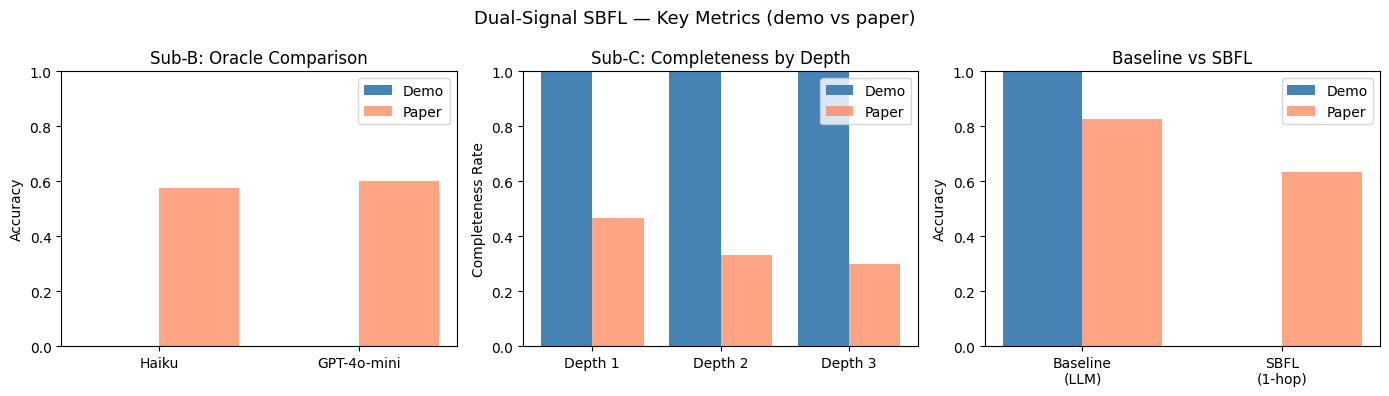

Figure saved to results_summary.png


In [14]:
print("=" * 60)
print("DUAL-SIGNAL SBFL — RESULTS SUMMARY")
print("=" * 60)

# Sub-experiment A
print(f"\nSub-A: Perturbation Calibration")
print(f"  Mean Spearman ρ : {result_A['mean_rho']}")
print(f"  Valid docs      : {result_A['n_valid']}/{result_A['n_total']}")
print(f"  Paper result    : mean_rho=0.261 (4/10 valid docs)")

# Sub-experiment B
print(f"\nSub-B: Oracle Model Comparison")
print(f"  Haiku  accuracy : {result_B['haiku']['accuracy']:.3f} ({result_B['haiku']['correct']}/{result_B['haiku']['total']})")
print(f"  GPT-4o accuracy : {result_B['gpt4o_mini']['accuracy']:.3f} ({result_B['gpt4o_mini']['correct']}/{result_B['gpt4o_mini']['total']})")
print(f"  Paper result    : haiku=0.575, gpt4o_mini=0.600")

# Sub-experiment C
print(f"\nSub-C: KB Completeness by Hop Depth")
for d in ["1", "2", "3"]:
    entry = result_C["by_depth"].get(d, {})
    comp = entry.get("completeness_rate", "N/A")
    sbfl = entry.get("sbfl_accuracy", "")
    sbfl_str = f", sbfl_acc={sbfl:.3f}" if sbfl != "" else ""
    print(f"  Depth {d}: completeness={comp:.3f}{sbfl_str} (n={entry.get('n_docs', 0)})")
print(f"  Paper result    : depth1=0.467/sbfl=0.633, depth2=0.333, depth3=0.300")

# Baseline
print(f"\nBaseline (direct LLM):")
print(f"  Accuracy : {baseline_result['accuracy']:.3f} ({baseline_result['correct']}/{baseline_result['total']})")
print(f"  Paper    : 0.825")

print(f"\nTotal LLM cost: ${cumulative_cost_usd:.4f}")
print(f"  Paper full run: $0.39 / $6 budget cap")

# Visualization: bar chart comparing key metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Dual-Signal SBFL — Key Metrics (demo vs paper)", fontsize=13)

# Plot 1: Oracle comparison
oracles = ["Haiku", "GPT-4o-mini"]
demo_accs = [result_B["haiku"]["accuracy"], result_B["gpt4o_mini"]["accuracy"]]
paper_accs = [0.575, 0.600]
x = range(len(oracles))
axes[0].bar([i - 0.2 for i in x], demo_accs, width=0.4, label="Demo", color="steelblue")
axes[0].bar([i + 0.2 for i in x], paper_accs, width=0.4, label="Paper", color="coral", alpha=0.7)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(oracles)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Sub-B: Oracle Comparison")
axes[0].set_ylim(0, 1)
axes[0].legend()

# Plot 2: Completeness by hop depth
depths = ["Depth 1", "Depth 2", "Depth 3"]
demo_comp = [result_C["by_depth"].get(str(d), {}).get("completeness_rate", 0) for d in [1, 2, 3]]
paper_comp = [0.467, 0.333, 0.300]
x = range(len(depths))
axes[1].bar([i - 0.2 for i in x], demo_comp, width=0.4, label="Demo", color="steelblue")
axes[1].bar([i + 0.2 for i in x], paper_comp, width=0.4, label="Paper", color="coral", alpha=0.7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(depths)
axes[1].set_ylabel("Completeness Rate")
axes[1].set_title("Sub-C: Completeness by Depth")
axes[1].set_ylim(0, 1)
axes[1].legend()

# Plot 3: Baseline vs SBFL accuracy
methods = ["Baseline\n(LLM)", "SBFL\n(1-hop)"]
demo_method_accs = [
    baseline_result["accuracy"],
    result_C["by_depth"].get("1", {}).get("sbfl_accuracy", 0),
]
paper_method_accs = [0.825, 0.633]
x = range(len(methods))
axes[2].bar([i - 0.2 for i in x], demo_method_accs, width=0.4, label="Demo", color="steelblue")
axes[2].bar([i + 0.2 for i in x], paper_method_accs, width=0.4, label="Paper", color="coral", alpha=0.7)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(methods)
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Baseline vs SBFL")
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to results_summary.png")